# Лабораторна робота №6
## Розробка нейронних мереж для обробки природної мови
### Датасет: IMDb Movie Reviews через Hugging Face `datasets` — аналіз тональності відгуків

У notebook реалізовано повний пайплайн згідно з вимогами лабораторної роботи:
- токенізація, побудова vocabulary та padding;
- модель `Embedding → BiLSTM/GRU → Self-Attention → FC`;
- 2-шарова двонаправлена LSTM (`bidirectional=True`);
- Dropout як регуляризація;
- експеримент із заморожуванням `Embedding`;
- порівняння з 1D-CNN за Accuracy, F1-score і часом навчання;
- візуалізація ваг уваги;
- висновки про LSTM, attention і порівняння архітектур.

## 1. Імпорт бібліотек та налаштування середовища

In [23]:
# !pip install -q -U datasets torch numpy pandas matplotlib scikit-learn

In [24]:
import torch

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("CUDA version in PyTorch:", torch.version.cuda)
print("GPU count:", torch.cuda.device_count())

if torch.cuda.is_available():
    print("GPU name:", torch.cuda.get_device_name(0))

PyTorch version: 2.11.0+cu128
CUDA available: True
CUDA version in PyTorch: 12.8
GPU count: 1
GPU name: NVIDIA GeForce RTX 3050 Laptop GPU


In [25]:
import time
import random
import re
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader

from datasets import load_dataset
from sklearn.metrics import f1_score, classification_report

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.backends.cudnn.deterministic = True

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Використовується пристрій: {device}')
if device.type == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')

Використовується пристрій: cuda
GPU: NVIDIA GeForce RTX 3050 Laptop GPU


## 2. Завантаження датасету IMDb через `datasets`

IMDb містить позитивні та негативні відгуки про фільми. Це бінарна задача класифікації тексту / аналізу тональності.

У цій версії notebook датасет завантажується через бібліотеку Hugging Face `datasets`, а не через `torchtext.datasets`.

In [26]:
print('Завантаження IMDb через Hugging Face datasets...')
imdb = load_dataset('imdb')

train_data = imdb['train']
test_data = imdb['test']

MAX_TRAIN_SAMPLES = None
MAX_TEST_SAMPLES = None

if MAX_TRAIN_SAMPLES is not None:
    train_data = train_data.shuffle(seed=SEED).select(range(MAX_TRAIN_SAMPLES))
if MAX_TEST_SAMPLES is not None:
    test_data = test_data.shuffle(seed=SEED).select(range(MAX_TEST_SAMPLES))

print(f'Кількість тренувальних прикладів: {len(train_data)}')
print(f'Кількість тестових прикладів:     {len(test_data)}')
print('\nПриклад запису:')
example = train_data[0]
print(f"Мітка: {example['label']} ({'positive' if example['label'] == 1 else 'negative'})")
print(f"Текст: {example['text'][:300]}...")

Завантаження IMDb через Hugging Face datasets...
Кількість тренувальних прикладів: 25000
Кількість тестових прикладів:     25000

Приклад запису:
Мітка: 0 (negative)
Текст: I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it when it was first released in 1967. I also heard that at first it was seized by U.S. customs if it ever tried to enter this country, therefore being a fan of films considered "controversial" I really h...


## 3. Попередня обробка: токенізація, vocabulary та padding

Виконуємо три обов'язкові етапи:
1. токенізація тексту;
2. побудова словника `vocab`;
3. padding послідовностей у межах батчу.

In [27]:
# Простий токенізатор без torchtext: lower-case + виділення слів і розділових знаків.
def tokenizer(text):
    return re.findall(r"\b\w+\b|[^\w\s]", text.lower())

SPECIALS = ['<unk>', '<pad>']
UNK_TOKEN = '<unk>'
PAD_TOKEN = '<pad>'
MIN_FREQ = 5
MAX_LEN = 256
BATCH_SIZE = 64


class Vocabulary:
    """Мінімальна реалізація vocabulary: token → index та список tokenів."""

    def __init__(self, counter, specials=None, min_freq=1):
        specials = specials or []
        self.itos = []
        self.stoi = {}

        for token in specials:
            self.add_token(token)

        for token, freq in counter.most_common():
            if freq >= min_freq and token not in self.stoi:
                self.add_token(token)

        self.default_index = self.stoi.get(UNK_TOKEN, 0)

    def add_token(self, token):
        self.stoi[token] = len(self.itos)
        self.itos.append(token)

    def __len__(self):
        return len(self.itos)

    def __getitem__(self, token):
        return self.stoi.get(token, self.default_index)

    def __call__(self, tokens):
        return [self[token] for token in tokens]

    def lookup_token(self, index):
        return self.itos[index]


def yield_tokens(data):
    for example in data:
        yield tokenizer(example['text'])


print('Побудова vocabulary...')
counter = Counter()
for tokens in yield_tokens(train_data):
    counter.update(tokens)

vocab = Vocabulary(counter, specials=SPECIALS, min_freq=MIN_FREQ)

PAD_IDX = vocab[PAD_TOKEN]
UNK_IDX = vocab[UNK_TOKEN]
VOCAB_SIZE = len(vocab)

print(f'Розмір vocabulary: {VOCAB_SIZE}')
print(f'PAD_IDX={PAD_IDX}, UNK_IDX={UNK_IDX}')
print(f'Приклади індексів: movie={vocab["movie"]}, good={vocab["good"]}, bad={vocab["bad"]}')

Побудова vocabulary...
Розмір vocabulary: 29170
PAD_IDX=1, UNK_IDX=0
Приклади індексів: movie=27, good=63, bad=90


In [28]:
def text_pipeline(text):
    """Токенізація + обрізання до MAX_LEN + перетворення токенів на індекси."""
    tokens = tokenizer(text)[:MAX_LEN]
    return vocab(tokens)


def label_pipeline(label):
    """Мітки в datasets/imdb уже числові: 0 = negative, 1 = positive."""
    return int(label)


def collate_batch(batch):
    """
    Формує батч із текстів різної довжини.
    Padding приводить усі речення до однакової довжини всередині батчу.
    """
    labels, texts, lengths = [], [], []

    for example in batch:
        label = example['label']
        text = example['text']
        token_ids = text_pipeline(text)

        # Захист від порожніх текстів після токенізації
        if len(token_ids) == 0:
            token_ids = [UNK_IDX]

        labels.append(label_pipeline(label))
        texts.append(torch.tensor(token_ids, dtype=torch.long))
        lengths.append(len(token_ids))

    padded_texts = nn.utils.rnn.pad_sequence(
        texts,
        batch_first=True,
        padding_value=PAD_IDX
    )

    return (
        torch.tensor(labels, dtype=torch.long).to(device),
        padded_texts.to(device),
        torch.tensor(lengths, dtype=torch.long).to(device)
    )


train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_batch)
test_loader = DataLoader(test_data, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_batch)

labels_b, texts_b, lengths_b = next(iter(train_loader))
print(f'Розмір батчу текстів: {texts_b.shape}')
print(f'Розмір батчу міток:  {labels_b.shape}')
print(f'Приклад lengths:     {lengths_b[:10].tolist()}')

Розмір батчу текстів: torch.Size([64, 256])
Розмір батчу міток:  torch.Size([64])
Приклад lengths:     [256, 256, 247, 145, 112, 191, 256, 159, 144, 178]


## 4. Модель 1: BiLSTM + Self-Attention

Модель відповідає вимогам лабораторної:
- використовує `nn.Embedding`;
- має мінімум два шари LSTM;
- є двонаправленою (`bidirectional=True`);
- має Dropout;
- поверх прихованих станів BiLSTM використовується `nn.MultiheadAttention`, тобто справжній механізм self-attention;
- padding токени маскуються через `key_padding_mask`.

In [29]:
class BiLSTMSelfAttentionClassifier(nn.Module):
    """
    Класифікатор текстів:
    Embedding → 2-layer Bidirectional LSTM → Multi-Head Self-Attention → masked mean pooling → FC logits.

    Вихід моделі — logits, тому для бінарної класифікації використовується BCEWithLogitsLoss.
    """

    def __init__(
        self,
        vocab_size,
        embed_dim,
        hidden_dim,
        output_dim,
        n_layers=2,
        dropout=0.5,
        pad_idx=0,
        num_attention_heads=8,
        freeze_embedding=False
    ):
        super().__init__()

        self.pad_idx = pad_idx
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        self.embedding.weight.requires_grad = not freeze_embedding

        self.lstm = nn.LSTM(
            input_size=embed_dim,
            hidden_size=hidden_dim,
            num_layers=n_layers,
            bidirectional=True,
            dropout=dropout if n_layers > 1 else 0.0,
            batch_first=True
        )

        lstm_output_dim = hidden_dim * 2
        self.self_attention = nn.MultiheadAttention(
            embed_dim=lstm_output_dim,
            num_heads=num_attention_heads,
            dropout=dropout,
            batch_first=True
        )

        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(lstm_output_dim, output_dim)

        self.last_token_importance = None
        self.last_key_padding_mask = None

    def _lengths_to_padding_mask(self, lengths, max_len):
        positions = torch.arange(max_len, device=lengths.device).unsqueeze(0)
        return positions >= lengths.unsqueeze(1)

    def forward(self, text, lengths):
        embedded = self.dropout(self.embedding(text))

        packed = nn.utils.rnn.pack_padded_sequence(
            embedded,
            lengths.cpu(),
            batch_first=True,
            enforce_sorted=False
        )
        packed_output, _ = self.lstm(packed)
        lstm_output, _ = nn.utils.rnn.pad_packed_sequence(
            packed_output,
            batch_first=True,
            total_length=text.size(1)
        )

        key_padding_mask = self._lengths_to_padding_mask(lengths, text.size(1))

        attn_output, attn_weights = self.self_attention(
            query=lstm_output,
            key=lstm_output,
            value=lstm_output,
            key_padding_mask=key_padding_mask,
            need_weights=True,
            average_attn_weights=False
        )

        token_importance = attn_weights.mean(dim=(1, 2))
        token_importance = token_importance.masked_fill(key_padding_mask, 0.0)
        token_importance = token_importance / token_importance.sum(dim=1, keepdim=True).clamp_min(1e-8)

        valid_mask = (~key_padding_mask).unsqueeze(-1).float()
        pooled = (attn_output * valid_mask).sum(dim=1) / valid_mask.sum(dim=1).clamp_min(1.0)

        self.last_token_importance = token_importance.detach()
        self.last_key_padding_mask = key_padding_mask.detach()

        logits = self.fc(self.dropout(pooled))
        return logits


# Гіперпараметри основної моделі
EMBED_DIM = 100
HIDDEN_DIM = 256
OUTPUT_DIM = 1
N_LAYERS = 2
DROPOUT = 0.5
N_HEADS = 8

lstm_model = BiLSTMSelfAttentionClassifier(
    vocab_size=VOCAB_SIZE,
    embed_dim=EMBED_DIM,
    hidden_dim=HIDDEN_DIM,
    output_dim=OUTPUT_DIM,
    n_layers=N_LAYERS,
    dropout=DROPOUT,
    pad_idx=PAD_IDX,
    num_attention_heads=N_HEADS,
    freeze_embedding=False
).to(device)

trainable_params = sum(p.numel() for p in lstm_model.parameters() if p.requires_grad)
total_params = sum(p.numel() for p in lstm_model.parameters())
print(f'BiLSTM + Self-Attention: trainable params = {trainable_params:,}; total params = {total_params:,}')
print(lstm_model)

BiLSTM + Self-Attention: trainable params = 6,278,281; total params = 6,278,281
BiLSTMSelfAttentionClassifier(
  (embedding): Embedding(29170, 100, padding_idx=1)
  (lstm): LSTM(100, 256, num_layers=2, batch_first=True, dropout=0.5, bidirectional=True)
  (self_attention): MultiheadAttention(
    (out_proj): NonDynamicallyQuantizableLinear(in_features=512, out_features=512, bias=True)
  )
  (dropout): Dropout(p=0.5, inplace=False)
  (fc): Linear(in_features=512, out_features=1, bias=True)
)


## 5. Модель 2: TextCNN / 1D-Convolution для порівняння

CNN-модель використовується як альтернативна архітектура. Вона аналізує локальні n-грамні шаблони за допомогою згорток із різними розмірами фільтрів.

In [30]:
class TextCNNClassifier(nn.Module):
    """
    TextCNN:
    Embedding → Conv1D з фільтрами 3/4/5 → ReLU → Global MaxPool → Dropout → FC logits.
    """

    def __init__(self, vocab_size, embed_dim, n_filters, filter_sizes, output_dim, dropout=0.5, pad_idx=0):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        self.convs = nn.ModuleList([
            nn.Conv1d(in_channels=embed_dim, out_channels=n_filters, kernel_size=fs)
            for fs in filter_sizes
        ])
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(n_filters * len(filter_sizes), output_dim)

    def forward(self, text, lengths=None):
        embedded = self.embedding(text)
        embedded = embedded.permute(0, 2, 1)

        pooled_outputs = []
        for conv in self.convs:
            conved = torch.relu(conv(embedded))
            pooled = conved.max(dim=2).values
            pooled_outputs.append(pooled)

        features = torch.cat(pooled_outputs, dim=1)
        logits = self.fc(self.dropout(features))
        return logits


N_FILTERS = 100
FILTER_SIZES = [3, 4, 5]

cnn_model = TextCNNClassifier(
    vocab_size=VOCAB_SIZE,
    embed_dim=EMBED_DIM,
    n_filters=N_FILTERS,
    filter_sizes=FILTER_SIZES,
    output_dim=OUTPUT_DIM,
    dropout=DROPOUT,
    pad_idx=PAD_IDX
).to(device)

cnn_trainable_params = sum(p.numel() for p in cnn_model.parameters() if p.requires_grad)
print(f'TextCNN: trainable params = {cnn_trainable_params:,}')
print(cnn_model)

TextCNN: trainable params = 3,037,601
TextCNNClassifier(
  (embedding): Embedding(29170, 100, padding_idx=1)
  (convs): ModuleList(
    (0): Conv1d(100, 100, kernel_size=(3,), stride=(1,))
    (1): Conv1d(100, 100, kernel_size=(4,), stride=(1,))
    (2): Conv1d(100, 100, kernel_size=(5,), stride=(1,))
  )
  (dropout): Dropout(p=0.5, inplace=False)
  (fc): Linear(in_features=300, out_features=1, bias=True)
)


## 6. Функції тренування та оцінки

Оцінюємо не лише Accuracy, а й F1-score. Для лабораторної це важливо, оскільки F1 краще показує баланс між precision і recall, особливо якщо класи незбалансовані.

In [31]:
def train_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, correct, total = 0.0, 0, 0

    for labels, texts, lengths in loader:
        optimizer.zero_grad()

        logits = model(texts, lengths).squeeze(1)
        loss = criterion(logits, labels.float())
        loss.backward()

        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        total_loss += loss.item()
        preds = (torch.sigmoid(logits) >= 0.5).long()
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    return total_loss / len(loader), correct / total


def evaluate(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels = [], []

    with torch.no_grad():
        for labels, texts, lengths in loader:
            logits = model(texts, lengths).squeeze(1)
            loss = criterion(logits, labels.float())

            total_loss += loss.item()
            preds = (torch.sigmoid(logits) >= 0.5).long()
            correct += (preds == labels).sum().item()
            total += labels.size(0)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    f1 = f1_score(all_labels, all_preds)
    return total_loss / len(loader), correct / total, f1


def train_model(model, train_loader, test_loader, n_epochs=5, lr=1e-3, model_name='Model'):
    criterion = nn.BCEWithLogitsLoss().to(device)
    optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=lr)

    history = {
        'train_loss': [], 'train_acc': [],
        'test_loss': [], 'test_acc': [], 'test_f1': [],
        'epoch_time': [], 'total_time': None
    }

    print('\n' + '=' * 86)
    print(f'Тренування: {model_name}')
    print('=' * 86)
    print(f'{"Epoch":<8}{"Train Loss":<14}{"Train Acc":<12}{"Test Loss":<13}{"Test Acc":<12}{"F1":<10}{"Time, s"}')
    print('-' * 86)

    start_total = time.time()
    for epoch in range(1, n_epochs + 1):
        start_epoch = time.time()

        train_loss, train_acc = train_epoch(model, train_loader, optimizer, criterion)
        test_loss, test_acc, test_f1 = evaluate(model, test_loader, criterion)

        epoch_time = time.time() - start_epoch

        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['test_loss'].append(test_loss)
        history['test_acc'].append(test_acc)
        history['test_f1'].append(test_f1)
        history['epoch_time'].append(epoch_time)

        print(f'{epoch:<8}{train_loss:<14.4f}{train_acc:<12.4f}{test_loss:<13.4f}{test_acc:<12.4f}{test_f1:<10.4f}{epoch_time:.1f}')

    history['total_time'] = time.time() - start_total
    print(f'Загальний час тренування: {history["total_time"]:.1f} с')
    return history

## 7. Тренування BiLSTM + Self-Attention

In [32]:
N_EPOCHS = 5

lstm_history = train_model(
    lstm_model,
    train_loader,
    test_loader,
    n_epochs=N_EPOCHS,
    lr=1e-3,
    model_name='BiLSTM + Multi-Head Self-Attention'
)


Тренування: BiLSTM + Multi-Head Self-Attention
Epoch   Train Loss    Train Acc   Test Loss    Test Acc    F1        Time, s
--------------------------------------------------------------------------------------
1       0.5682        0.6974      0.4182       0.8040      0.8061    93.5
2       0.4166        0.8111      0.3413       0.8464      0.8469    93.8
3       0.3451        0.8507      0.3323       0.8575      0.8650    93.8
4       0.3000        0.8748      0.3404       0.8629      0.8713    93.8
5       0.2680        0.8912      0.3462       0.8693      0.8771    94.4
Загальний час тренування: 469.3 с


## 8. Тренування TextCNN

In [33]:
cnn_history = train_model(
    cnn_model,
    train_loader,
    test_loader,
    n_epochs=N_EPOCHS,
    lr=1e-3,
    model_name='TextCNN / 1D-Convolution'
)


Тренування: TextCNN / 1D-Convolution
Epoch   Train Loss    Train Acc   Test Loss    Test Acc    F1        Time, s
--------------------------------------------------------------------------------------
1       0.6351        0.6469      0.5108       0.7394      0.7778    11.5
2       0.5053        0.7474      0.4284       0.8073      0.7914    11.2
3       0.4309        0.8009      0.3634       0.8386      0.8442    11.3
4       0.3695        0.8356      0.3388       0.8510      0.8471    11.1
5       0.3104        0.8675      0.3408       0.8509      0.8428    11.1
Загальний час тренування: 56.2 с


## 9. Експеримент із заморожуванням шару Embedding

Заморожування `Embedding` виконано: порівнюється модель, де embedding навчається, і модель, де embedding заморожений (`requires_grad=False`).

In [34]:
FREEZE_EPOCHS = 5

embedding_experiment = {}

for freeze in [False, True]:
    model_name = 'Embedding trainable' if not freeze else 'Embedding frozen'
    print(f'\nЕксперимент: {model_name}')

    model_emb = BiLSTMSelfAttentionClassifier(
        vocab_size=VOCAB_SIZE,
        embed_dim=EMBED_DIM,
        hidden_dim=HIDDEN_DIM,
        output_dim=OUTPUT_DIM,
        n_layers=N_LAYERS,
        dropout=DROPOUT,
        pad_idx=PAD_IDX,
        num_attention_heads=N_HEADS,
        freeze_embedding=freeze
    ).to(device)

    history_emb = train_model(
        model_emb,
        train_loader,
        test_loader,
        n_epochs=FREEZE_EPOCHS,
        lr=1e-3,
        model_name=model_name
    )

    embedding_experiment[model_name] = {
        'accuracy': history_emb['test_acc'][-1],
        'f1': history_emb['test_f1'][-1],
        'total_time': history_emb['total_time'],
        'embedding_trainable': model_emb.embedding.weight.requires_grad
    }

pd.DataFrame(embedding_experiment).T


Експеримент: Embedding trainable

Тренування: Embedding trainable
Epoch   Train Loss    Train Acc   Test Loss    Test Acc    F1        Time, s
--------------------------------------------------------------------------------------
1       0.5638        0.6988      0.4392       0.7900      0.7649    94.1
2       0.4094        0.8156      0.3384       0.8505      0.8510    93.9
3       0.3429        0.8513      0.3213       0.8636      0.8688    94.3
4       0.3020        0.8724      0.3055       0.8721      0.8772    94.8
5       0.2691        0.8906      0.2967       0.8744      0.8791    94.8
Загальний час тренування: 471.9 с

Експеримент: Embedding frozen

Тренування: Embedding frozen
Epoch   Train Loss    Train Acc   Test Loss    Test Acc    F1        Time, s
--------------------------------------------------------------------------------------
1       0.6161        0.6561      0.5626       0.7008      0.7588    92.7
2       0.5050        0.7530      0.5011       0.7637      0.7986 

,accuracy,f1,total_time,embedding_trainable
Embedding trainable,0.87436,0.879132,471.856533,True
Embedding frozen,0.8304,0.847865,466.536255,False


## 10. Порівняння BiLSTM + Self-Attention і TextCNN

Порівнюємо фінальні метрики та швидкість навчання.

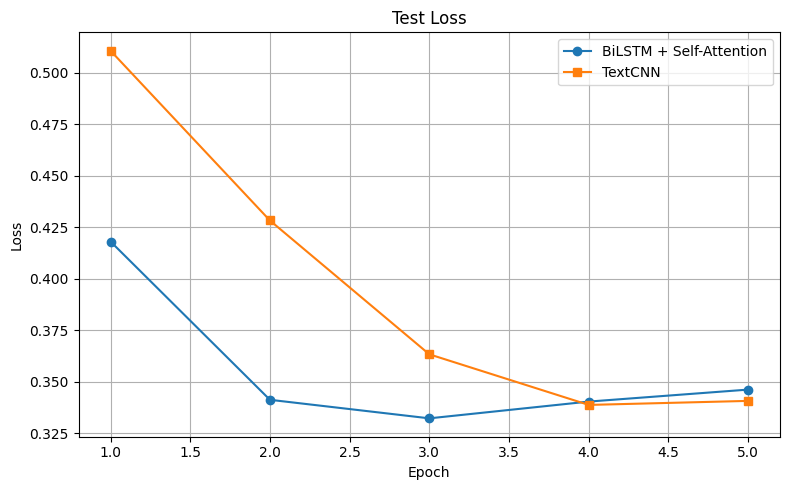

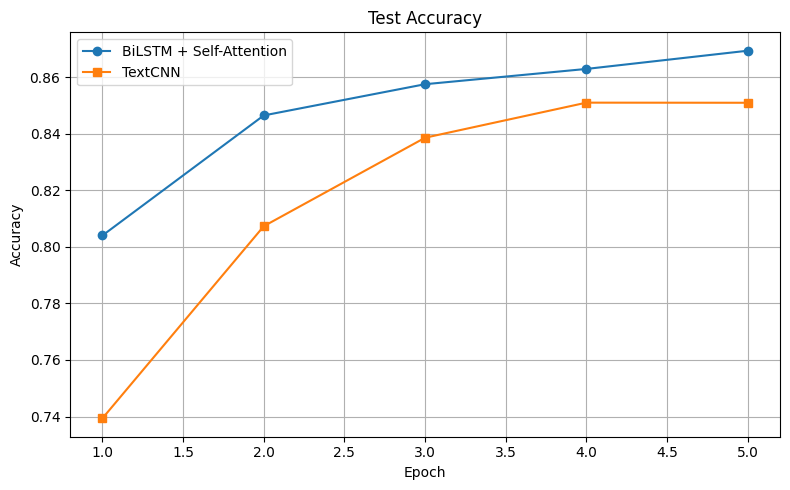

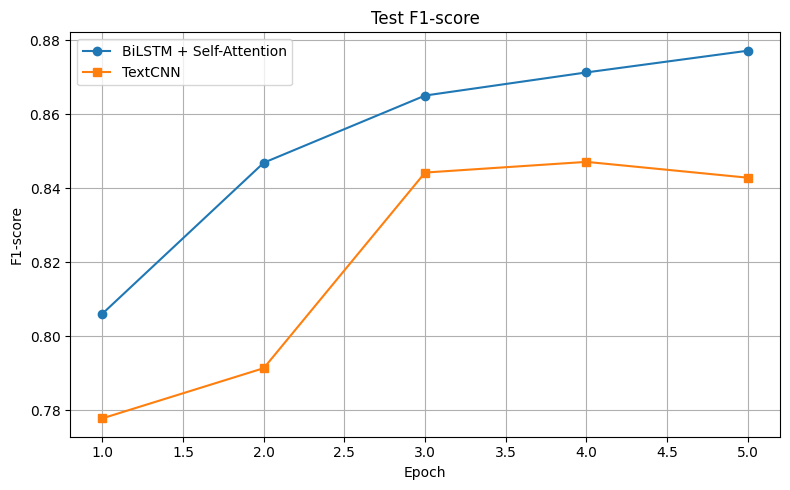

,Model,Final Accuracy,Final F1-score,"Total train time, s",Trainable parameters
0,BiLSTM + Self-Attention,0.86932,0.877148,469.293783,6278281
1,TextCNN / 1D-Convolution,0.85092,0.842829,56.174525,3037601


In [35]:
epochs = range(1, N_EPOCHS + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs, lstm_history['test_loss'], marker='o', label='BiLSTM + Self-Attention')
plt.plot(epochs, cnn_history['test_loss'], marker='s', label='TextCNN')
plt.title('Test Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(epochs, lstm_history['test_acc'], marker='o', label='BiLSTM + Self-Attention')
plt.plot(epochs, cnn_history['test_acc'], marker='s', label='TextCNN')
plt.title('Test Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(epochs, lstm_history['test_f1'], marker='o', label='BiLSTM + Self-Attention')
plt.plot(epochs, cnn_history['test_f1'], marker='s', label='TextCNN')
plt.title('Test F1-score')
plt.xlabel('Epoch')
plt.ylabel('F1-score')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

comparison_df = pd.DataFrame({
    'Model': ['BiLSTM + Self-Attention', 'TextCNN / 1D-Convolution'],
    'Final Accuracy': [lstm_history['test_acc'][-1], cnn_history['test_acc'][-1]],
    'Final F1-score': [lstm_history['test_f1'][-1], cnn_history['test_f1'][-1]],
    'Total train time, s': [lstm_history['total_time'], cnn_history['total_time']],
    'Trainable parameters': [
        sum(p.numel() for p in lstm_model.parameters() if p.requires_grad),
        sum(p.numel() for p in cnn_model.parameters() if p.requires_grad)
    ]
})

comparison_df

## 11. Детальний classification report для основної моделі

In [36]:
criterion = nn.BCEWithLogitsLoss().to(device)
lstm_model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for labels, texts, lengths in test_loader:
        logits = lstm_model(texts, lengths).squeeze(1)
        preds = (torch.sigmoid(logits) >= 0.5).long()
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

print('Classification Report — BiLSTM + Self-Attention')
print(classification_report(all_labels, all_preds, target_names=['Негативний', 'Позитивний']))

Classification Report — BiLSTM + Self-Attention
              precision    recall  f1-score   support

  Негативний       0.92      0.81      0.86     12500
  Позитивний       0.83      0.93      0.88     12500

    accuracy                           0.87     25000
   macro avg       0.88      0.87      0.87     25000
weighted avg       0.88      0.87      0.87     25000



## 12. Візуалізація ваг уваги

Візуалізація показує, які токени отримали найбільшу середню attention-важливість у self-attention шарі.

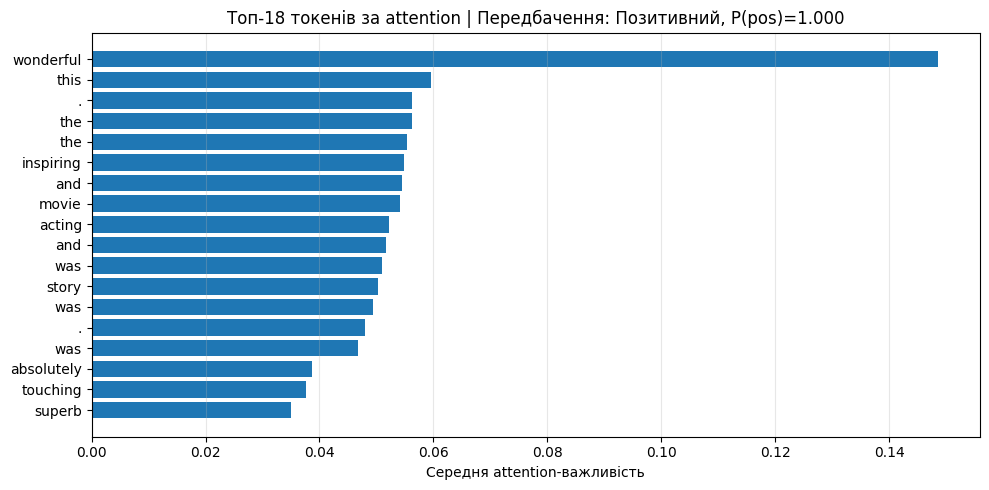

Текст: This movie was absolutely wonderful. The acting was superb and the story was touching and inspiring.
Передбачення: Позитивний; P(позитивний)=1.0000


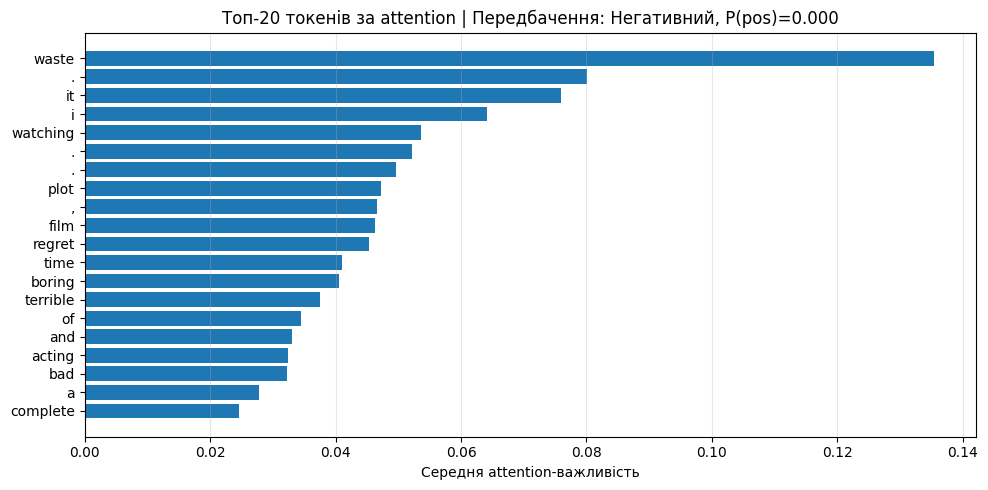

Текст: Terrible film. Boring plot, bad acting and a complete waste of time. I regret watching it.
Передбачення: Негативний; P(позитивний)=0.0000


In [37]:
def visualize_attention(model, text, tokenizer, vocab, max_len=256, top_n=20):
    model.eval()
    tokens = tokenizer(text)[:max_len]
    ids = vocab(tokens)
    if len(ids) == 0:
        ids = [UNK_IDX]
        tokens = [UNK_TOKEN]

    text_tensor = torch.tensor([ids], dtype=torch.long).to(device)
    length_tensor = torch.tensor([len(ids)], dtype=torch.long).to(device)

    with torch.no_grad():
        logits = model(text_tensor, length_tensor)
        prob = torch.sigmoid(logits).item()
        pred_label = 'Позитивний' if prob >= 0.5 else 'Негативний'

    importance = model.last_token_importance[0, :len(tokens)].cpu().numpy()

    n = min(top_n, len(tokens))
    top_idx = np.argsort(importance)[-n:][::-1]
    top_tokens = [tokens[i] for i in top_idx]
    top_importance = importance[top_idx]

    plt.figure(figsize=(10, 5))
    plt.barh(range(n), top_importance)
    plt.yticks(range(n), top_tokens)
    plt.gca().invert_yaxis()
    plt.xlabel('Середня attention-важливість')
    plt.title(f'Топ-{n} токенів за attention | Передбачення: {pred_label}, P(pos)={prob:.3f}')
    plt.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.show()

    print(f'Текст: {text}')
    print(f'Передбачення: {pred_label}; P(позитивний)={prob:.4f}')


example_pos = 'This movie was absolutely wonderful. The acting was superb and the story was touching and inspiring.'
example_neg = 'Terrible film. Boring plot, bad acting and a complete waste of time. I regret watching it.'

visualize_attention(lstm_model, example_pos, tokenizer, vocab)
visualize_attention(lstm_model, example_neg, tokenizer, vocab)

## 13. Дослідження впливу Dropout

Додатково перевіряємо, як різні значення Dropout впливають на якість BiLSTM + Self-Attention. Це розділ регуляризації в NLP.

In [38]:
DROPOUT_EPOCHS = 2
dropout_results = {}

for dp in [0.0, 0.3, 0.5]:
    print(f'\nDropout = {dp}')
    model_dp = BiLSTMSelfAttentionClassifier(
        vocab_size=VOCAB_SIZE,
        embed_dim=EMBED_DIM,
        hidden_dim=HIDDEN_DIM,
        output_dim=OUTPUT_DIM,
        n_layers=N_LAYERS,
        dropout=dp,
        pad_idx=PAD_IDX,
        num_attention_heads=N_HEADS,
        freeze_embedding=False
    ).to(device)

    history_dp = train_model(
        model_dp,
        train_loader,
        test_loader,
        n_epochs=DROPOUT_EPOCHS,
        lr=1e-3,
        model_name=f'BiLSTM + Self-Attention, dropout={dp}'
    )

    dropout_results[dp] = {
        'accuracy': history_dp['test_acc'][-1],
        'f1': history_dp['test_f1'][-1],
        'total_time': history_dp['total_time']
    }

pd.DataFrame(dropout_results).T


Dropout = 0.0

Тренування: BiLSTM + Self-Attention, dropout=0.0
Epoch   Train Loss    Train Acc   Test Loss    Test Acc    F1        Time, s
--------------------------------------------------------------------------------------
1       0.4924        0.7548      0.3759       0.8308      0.8269    92.5
2       0.3034        0.8718      0.3347       0.8560      0.8628    92.7
Загальний час тренування: 185.2 с

Dropout = 0.3

Тренування: BiLSTM + Self-Attention, dropout=0.3
Epoch   Train Loss    Train Acc   Test Loss    Test Acc    F1        Time, s
--------------------------------------------------------------------------------------
1       0.5338        0.7265      0.4182       0.8085      0.8251    94.9
2       0.3591        0.8404      0.3269       0.8584      0.8565    94.9
Загальний час тренування: 189.9 с

Dropout = 0.5

Тренування: BiLSTM + Self-Attention, dropout=0.5
Epoch   Train Loss    Train Acc   Test Loss    Test Acc    F1        Time, s
------------------------------------

,accuracy,f1,total_time
0.0,0.85600,0.862826,185.205046
0.3,0.85840,0.856541,189.866111
0.5,0.83564,0.848023,189.811819


## 14. Тестування на власному тексті

In [ ]:
def predict_sentiment(text, model=lstm_model, temperature=2.0):
    model.eval()
    tokens = tokenizer(text)[:MAX_LEN]
    ids = vocab(tokens)
    if len(ids) == 0:
        ids = [UNK_IDX]

    text_tensor = torch.tensor([ids], dtype=torch.long).to(device)
    length_tensor = torch.tensor([len(ids)], dtype=torch.long).to(device)

    with torch.no_grad():
        prob = torch.sigmoid(model(text_tensor, length_tensor)/ temperature).item()

    sentiment = 'ПОЗИТИВНИЙ' if prob >= 0.5 else 'НЕГАТИВНИЙ'
    confidence = prob if prob >= 0.5 else 1 - prob

    print(f'Текст: {text}')
    print(f'Тональність: {sentiment}')
    print(f'Впевненість: {confidence:.2%}')
    return prob


my_review = 'bad movie. But actor was cool,'
predict_sentiment(my_review)

Текст: bad movie. But actor was cool, recommend
Тональність: ПОЗИТИВНИЙ
Впевненість: 95.42%


0.9542471170425415

## 15. Відповідність вимогам лабораторної

| Вимога | Реалізація в notebook |
|---|---|
| Обрати текстовий датасет | IMDb Movie Reviews через `datasets.load_dataset('imdb')` |
| Токенізація | власний regex-токенізатор `tokenizer` |
| Vocabulary | власний клас `Vocabulary` + `Counter` |
| Padding | `pad_sequence` у `collate_batch` |
| `nn.Embedding` | у BiLSTM і TextCNN |
| Мінімум 2 шари LSTM/GRU | `N_LAYERS = 2` |
| Bidirectional | `bidirectional=True` |
| Dropout | в LSTM, self-attention і перед FC |
| Freeze Embedding | окремий експеримент `Embedding trainable` vs `Embedding frozen` |
| CNN-порівняння | `TextCNNClassifier` з `Conv1d` |
| Метрики | Accuracy, F1-score, `classification_report` |
| Швидкість навчання | `epoch_time` і `total_time` |
| Self-Attention | `nn.MultiheadAttention` поверх BiLSTM hidden states |
| Візуалізація уваги | `visualize_attention` |
| Висновки | наведені нижче |

## 16. Висновки

### 1. Переваги LSTM над звичайними RNN

Звичайні RNN мають проблему зникаючого градієнта: під час зворотного поширення помилки через довгі послідовності градієнти можуть ставати дуже малими, тому модель погано запам'ятовує далекі залежності. LSTM вирішує цю проблему завдяки комірці пам'яті та трьом гейтам:

- **forget gate** визначає, яку стару інформацію забути;
- **input gate** визначає, яку нову інформацію записати;
- **output gate** визначає, яку частину пам'яті передати далі.

Тому LSTM краще підходить для текстів, де важливі слова можуть бути розташовані далеко одне від одного.

### 2. Як attention допомагає на довгих реченнях

Навіть BiLSTM стискає інформацію про послідовність у приховані стани, тому частина інформації з довгих речень може втрачатися. Self-Attention дозволяє кожному токену взаємодіяти з іншими токенами незалежно від відстані між ними. У цій роботі `nn.MultiheadAttention` аналізує приховані стани BiLSTM і допомагає моделі виділяти найважливіші слова для класифікації тональності.

### 3. Порівняння BiLSTM + Self-Attention і TextCNN

- **BiLSTM + Self-Attention** краще враховує довготривалий контекст і порядок слів, але зазвичай навчається повільніше.
- **TextCNN** швидше навчається і добре знаходить локальні n-грамні шаблони, наприклад `very good`, `waste of time`, але гірше моделює довгі залежності.
- Для IMDb обидва підходи можуть показати високу якість, але остаточний вибір залежить від F1-score, часу навчання і обмежень обчислювальних ресурсів.

### 4. Регуляризація

Dropout зменшує перенавчання, випадково вимикаючи частину нейронів під час тренування. Заморожування `Embedding` зменшує кількість trainable-параметрів і може пришвидшити навчання, але якщо embedding не є попередньо навченим, якість часто знижується, бо модель не може адаптувати представлення слів до конкретного датасету.